In [ ]:
# Local/WSL workflow: no Colab drive mount needed.


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import mixed_precision

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

if gpus:
    mixed_precision.set_global_policy("mixed_float16")

print("TF version:", tf.__version__)
print("GPU:", gpus)
print("Mixed precision policy:", mixed_precision.global_policy())

from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import numpy as np

2026-03-10 20:28:09.903796: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-10 20:28:14.398603: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-10 20:28:29.744474: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


In [2]:
import os
import random
import keras_hub
from collections import Counter
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)


/home/dell/miniconda3/envs/tf218/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def count_files_by_class(root_dir):
    counts = {}
    for class_name in sorted(os.listdir(root_dir)):
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        counts[class_name] = sum(
            1
            for file_name in os.listdir(class_dir)
            if file_name.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
        )
    return counts


def summarize_labels(ds, class_names):
    counts = Counter()
    for _, labels in ds:
        labels = labels.numpy().astype("int32").reshape(-1)
        counts.update(labels.tolist())
    return {class_names[idx]: counts.get(idx, 0) for idx in range(len(class_names))}


In [4]:
# Dataset path is configured in the next cell.


In [5]:
data_dir = "/mnt/e/DDSM/ROI"
assert os.path.exists(data_dir), f"Dataset path not found: {data_dir}"

In [6]:
raw_class_counts = count_files_by_class(data_dir)
print("Raw file counts by class:", raw_class_counts)


Raw file counts by class: {'ROI_Benign': 1402, 'ROI_Cancer': 1428}


Quick check: inspect one training batch after the dataset cell runs.

Diagnostics: verify split sizes, class balance, and one sample batch before training.

In [7]:
img_size = (224, 224)
batch_size = 16
seed = 123
AUTOTUNE = tf.data.AUTOTUNE

os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
keras.utils.set_random_seed(seed)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
)

class_names = train_ds.class_names
print("Classes:", class_names)
print(f"Positive class for AUC/ROC: {class_names[1]}")

temp_card = tf.data.experimental.cardinality(temp_ds).numpy()
if temp_card < 2:
    raise ValueError(f"Validation split is too small: only {temp_card} batch(es). Reduce batch_size or use more data.")

val_batches = max(1, temp_card // 2)
test_batches = temp_card - val_batches
if test_batches == 0:
    raise ValueError("Test split is empty. Reduce batch_size or use more data.")

val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

def prepare(ds, shuffle=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=seed, reshuffle_each_iteration=True)
    return ds.prefetch(AUTOTUNE)

train_ds_prep = prepare(train_ds, shuffle=True)
val_ds_prep = prepare(val_ds)
test_ds_prep = prepare(test_ds)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

train_label_counts = summarize_labels(train_ds, class_names)
val_label_counts = summarize_labels(val_ds, class_names)
test_label_counts = summarize_labels(test_ds, class_names)

print("Train label counts:", train_label_counts)
print("Validation label counts:", val_label_counts)
print("Test label counts:", test_label_counts)


Found 2830 files belonging to 2 classes.
Using 2264 files for training.


I0000 00:00:1773145897.712250     655 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 2830 files belonging to 2 classes.
Using 566 files for validation.
Classes: ['ROI_Benign', 'ROI_Cancer']
Positive class for AUC/ROC: ROI_Cancer
Train batches: 283
Validation batches: 35
Test batches: 36


2026-03-10 20:32:10.141977: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-10 20:32:13.768043: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Train label counts: {'ROI_Benign': 1123, 'ROI_Cancer': 1141}
Validation label counts: {'ROI_Benign': 143, 'ROI_Cancer': 137}
Test label counts: {'ROI_Benign': 145, 'ROI_Cancer': 141}


In [8]:
for images, labels in train_ds.take(1):
    print("image batch:", images.shape)
    print("label batch:", labels.shape)
    print("labels:", labels[:8].numpy().reshape(-1))


image batch: (8, 224, 224, 3)
label batch: (8, 1)
labels: [1. 0. 0. 0. 0. 1. 0. 1.]


2026-03-10 20:32:16.760556: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.10),
    keras.layers.RandomZoom(0.20),
    keras.layers.RandomTranslation(0.05, 0.05),
    keras.layers.RandomContrast(0.20),
], name="data_augmentation")


In [10]:
backbone = keras_hub.models.ViTBackbone.from_preset(
    "vit_base_patch16_224_imagenet21k"
)

preprocessing = keras.Sequential(
    [keras.layers.Rescaling(1.0 / 255)],
    name="preprocessing"
)

inputs = keras.Input(shape=img_size + (3,))
x = preprocessing(inputs)
x = data_augmentation(x)
x = backbone(x)
x = x[:, 0, :]  # CLS token
x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid", dtype="float32", name="cancer_prob")(x)

model = keras.Model(inputs, outputs)
print("Backbone type:", type(backbone).__name__)
print("Model output shape:", model.output_shape)
model.summary()


Backbone type: ViTBackbone
Model output shape: (None, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cancer_prob (Dense)             │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,996,801 (328.05 MB)

 Trainable params: 85,996,289 (328.05 MB)

 Non-trainable params: 512 (2.00 KB)

In [11]:
backbone.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

stage1_trainable_weights = len(model.trainable_weights)
print("Stage 1 monitor: val_auc")
print("Stage 1 trainable weights:", stage1_trainable_weights)

stage1_ckpt = "/mnt/e/SW_training_outputs/checkpoints/best_vit_stage1.keras"
cb1 = [
    keras.callbacks.ModelCheckpoint(
        stage1_ckpt,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
]

history1 = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=10,
    callbacks=cb1,
    verbose=1,
)


Stage 1 monitor: val_auc
Stage 1 trainable weights: 6
Epoch 1/10


2026-03-10 20:32:33.174335: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-03-10 20:32:37.290004: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300


283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - acc: 0.5273 - auc: 0.5540 - loss: 0.7364 - precision: 0.5327 - recall: 0.5068
Epoch 1: val_auc improved from None to 0.65126, saving model to best_vit_stage1.keras

Epoch 1: finished saving model to best_vit_stage1.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 42s 91ms/step - acc: 0.5517 - auc: 0.5818 - loss: 0.7225 - precision: 0.5578 - recall: 0.5329 - val_acc: 0.6143 - val_auc: 0.6513 - val_loss: 0.6763 - val_precision: 0.6122 - val_recall: 0.6383
Epoch 2/10


2026-03-10 20:33:19.338883: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 106 of 1000
2026-03-10 20:33:37.034205: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - acc: 0.5804 - auc: 0.6132 - loss: 0.7010 - precision: 0.5705 - recall: 0.5802
Epoch 2: val_auc improved from 0.65126 to 0.68029, saving model to best_vit_stage1.keras

Epoch 2: finished saving model to best_vit_stage1.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - acc: 0.5808 - auc: 0.6135 - loss: 0.6999 - precision: 0.5863 - recall: 0.5714 - val_acc: 0.5679 - val_auc: 0.6803 - val_loss: 0.7009 - val_precision: 0.8125 - val_recall: 0.1844
Epoch 3/10


2026-03-10 20:34:10.238702: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 90 of 1000
2026-03-10 20:34:19.378694: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - acc: 0.5789 - auc: 0.6208 - loss: 0.6851 - precision: 0.5973 - recall: 0.5820
Epoch 3: val_auc did not improve from 0.68029
283/283 ━━━━━━━━━━━━━━━━━━━━ 40s 71ms/step - acc: 0.5804 - auc: 0.6145 - loss: 0.6932 - precision: 0.5843 - recall: 0.5802 - val_acc: 0.6071 - val_auc: 0.6587 - val_loss: 0.6537 - val_precision: 0.6508 - val_recall: 0.5541
Epoch 4/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - acc: 0.5860 - auc: 0.6155 - loss: 0.6903 - precision: 0.5813 - recall: 0.5788
Epoch 4: val_auc did not improve from 0.68029
283/283 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - acc: 0.5782 - auc: 0.6121 - loss: 0.6936 - precision: 0.5839 - recall: 0.5670 - val_acc: 0.5857 - val_auc: 0.6467 - val_loss: 0.6606 - val_precision: 0.5751 - val_recall: 0.7655
Epoch 5/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - acc: 0.5616 - auc: 0.5909 - loss: 0.6975 - precision: 0.5563 - recall: 0.5379
Epoch 5: val_auc did not improve from 0.68029
283/283 ━━━━━━━━━━━━━━━━━━━━

In [12]:
# Stage 2: fine-tune only the last few transformer blocks.
backbone.trainable = True
num_blocks_to_unfreeze = 2

all_backbone_layers = list(backbone._flatten_layers(include_self=False, recursive=True))
for layer in all_backbone_layers:
    layer.trainable = False

transformer_blocks = [
    layer for layer in all_backbone_layers
    if "tranformer_block" in layer.name
]

if not transformer_blocks:
    candidate_names = [
        layer.name for layer in all_backbone_layers
        if any(token in layer.name.lower() for token in ["vit", "patch", "encoder", "block"])
    ]
    raise ValueError(
        "No tranformer blocks found in backbone. Candidates: " + ", ".join(candidate_names[:30])
    )

print("Found tranformer blocks:", len(transformer_blocks))
print("Last 6 tranformer block names:", [layer.name for layer in transformer_blocks[-6:]])

for layer in transformer_blocks[-num_blocks_to_unfreeze:]:
    layer.trainable = True

patching_layer = backbone.get_layer("vit_patching_and_embedding")
unfrozen_block_names = [layer.name for layer in transformer_blocks[-num_blocks_to_unfreeze:]]
stage2_trainable_weights = len(model.trainable_weights)
print("Stage 2 monitor: val_auc")
print("Stage 1 trainable weights:", stage1_trainable_weights)
print("Stage 2 trainable weights:", stage2_trainable_weights)
print("Additional trainable weights after unfreezing:", stage2_trainable_weights - stage1_trainable_weights)
print("Patching/embedding trainable:", patching_layer.trainable)
print("Unfrozen transformer blocks:", unfrozen_block_names)

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4,
    ),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

ckpt_path = "/mnt/e/SW_training_outputs/checkpoints/best_vit_model.keras"
cb2 = [
    keras.callbacks.ModelCheckpoint(
        ckpt_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

history2 = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=25,
    initial_epoch=len(history1.history["loss"]),
    callbacks=cb2,
    verbose=1,
)


Found tranformer blocks: 12
Last 6 tranformer block names: ['tranformer_block_6', 'tranformer_block_5', 'tranformer_block_4', 'tranformer_block_3', 'tranformer_block_2', 'tranformer_block_1']
Stage 2 monitor: val_auc
Stage 1 trainable weights: 6
Stage 2 trainable weights: 38
Additional trainable weights after unfreezing: 32
Patching/embedding trainable: False
Unfrozen transformer blocks: ['tranformer_block_2', 'tranformer_block_1']
Epoch 6/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - acc: 0.5756 - auc: 0.6109 - loss: 0.6955 - precision: 0.5759 - recall: 0.5663
Epoch 6: val_auc improved from None to 0.64350, saving model to best_vit_model.keras

Epoch 6: finished saving model to best_vit_model.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 60s 175ms/step - acc: 0.5632 - auc: 0.5979 - loss: 0.7036 - precision: 0.5679 - recall: 0.5574 - val_acc: 0.5964 - val_auc: 0.6435 - val_loss: 0.6572 - val_precision: 0.6187 - val_recall: 0.5890
Epoch 7/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - acc: 0.58

2026-03-10 20:37:27.148742: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 112 of 1000
2026-03-10 20:37:35.366307: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - acc: 0.5661 - auc: 0.5905 - loss: 0.7078 - precision: 0.5724 - recall: 0.5623
Epoch 8: val_auc improved from 0.66557 to 0.68891, saving model to best_vit_model.keras

Epoch 8: finished saving model to best_vit_model.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 69s 179ms/step - acc: 0.5826 - auc: 0.6155 - loss: 0.6908 - precision: 0.5878 - recall: 0.5749 - val_acc: 0.6393 - val_auc: 0.6889 - val_loss: 0.6462 - val_precision: 0.7245 - val_recall: 0.4897
Epoch 9/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - acc: 0.5918 - auc: 0.6226 - loss: 0.6798 - precision: 0.6001 - recall: 0.5821
Epoch 9: val_auc did not improve from 0.68891
283/283 ━━━━━━━━━━━━━━━━━━━━ 47s 163ms/step - acc: 0.5870 - auc: 0.6238 - loss: 0.6788 - precision: 0.5936 - recall: 0.5723 - val_acc: 0.6286 - val_auc: 0.6795 - val_loss: 0.6509 - val_precision: 0.7126 - val_recall: 0.4397
Epoch 10/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - acc: 0.6165 - auc: 0.6512 - loss: 0.6593 - preci

In [13]:
print("Backbone trainable:", backbone.trainable)
print("Trainable weights:", len(model.trainable_weights))
print("Found tranformer blocks:", len(transformer_blocks))
print("Unfrozen transformer blocks:", unfrozen_block_names)
for name in unfrozen_block_names:
    layer = next(l for l in transformer_blocks if l.name == name)
    print(layer.name, layer.trainable)


Backbone trainable: True
Trainable weights: 38
Found tranformer blocks: 12
Unfrozen transformer blocks: ['tranformer_block_2', 'tranformer_block_1']
tranformer_block_2 True
tranformer_block_1 True


In [14]:
best_model = keras.models.load_model(ckpt_path)
best_model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)
print("Loaded best model from:", ckpt_path)
print("Best model output shape:", best_model.output_shape)


Loaded best model from: best_vit_model.keras
Best model output shape: (None, 1)


/home/dell/miniconda3/envs/tf218/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 414 variables whereas the saved optimizer has 82 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/dell/miniconda3/envs/tf218/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 410 variables whereas the saved optimizer has 78 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [15]:
test_metrics = best_model.evaluate(test_ds_prep, return_dict=True)
if not isinstance(test_metrics, dict):
    raise TypeError(
        f"Expected evaluate(..., return_dict=True) to return dict, got {type(test_metrics).__name__}. "
        "Restart the kernel and rerun the notebook from the import cells."
    )
print("Evaluation metrics:", test_metrics)


36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - acc: 0.6329 - auc: 0.6686 - loss: 0.6535 - precision: 0.7071 - recall: 0.4795
Evaluation metrics: {'acc': 0.632867157459259, 'auc': 0.668615460395813, 'loss': 0.6535256505012512, 'precision': 0.7070707082748413, 'recall': 0.4794520437717438}


Positive class for ROC/AUC: ROI_Cancer
First 20 y_true: [1 1 1 1 0 1 1 0 1 0 1 0 1 1 0 1 0 0 0 1]
First 20 y_prob: [0.4583 0.8251 0.6998 0.3934 0.3927 0.1658 0.6098 0.4893 0.6787 0.1493
 0.3986 0.1856 0.566  0.3641 0.2597 0.3467 0.3638 0.3397 0.4404 0.5813]
Probability range: 0.09966611862182617 0.895889163017273
Probability mean/std: 0.4559275507926941 0.15894393622875214
Test AUC: 0.6877
Test Accuracy: 0.6329
Confusion Matrix:
 [[107  28]
 [ 77  74]]
Classification Report:
               precision    recall  f1-score   support

  ROI_Benign       0.58      0.79      0.67       135
  ROI_Cancer       0.73      0.49      0.58       151

    accuracy                           0.63       286
   macro avg       0.65      0.64      0.63       286
weighted avg       0.66      0.63      0.63       286



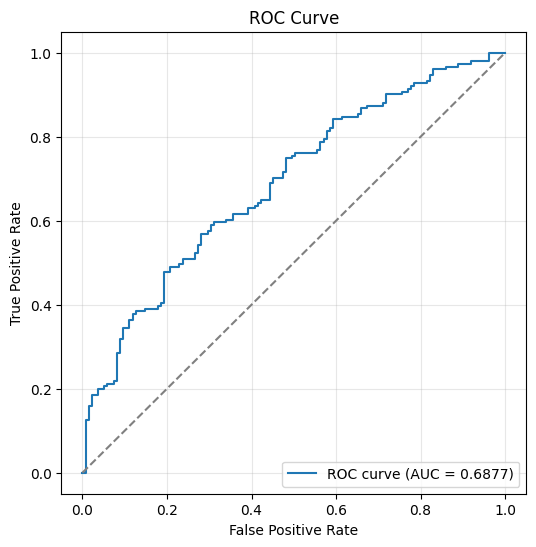

In [16]:
y_true = []
y_prob = []

for xb, yb in test_ds_prep:
    pb = best_model.predict(xb, verbose=0).reshape(-1)
    y_true.append(yb.numpy().reshape(-1))
    y_prob.append(pb)

y_true = np.concatenate(y_true).astype("int32")
y_prob = np.concatenate(y_prob)
y_pred = (y_prob >= 0.5).astype("int32")

print("Positive class for ROC/AUC:", class_names[1])
print("First 20 y_true:", y_true[:20])
print("First 20 y_prob:", np.round(y_prob[:20], 4))
print("Probability range:", float(y_prob.min()), float(y_prob.max()))
print("Probability mean/std:", float(y_prob.mean()), float(y_prob.std()))

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"Test AUC: {auc:.4f}")
print(f"Test Accuracy: {acc:.4f}")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_names))
if auc < 0.55:
    print("AUC is below 0.55. Stop tuning ViT further and run the ResNet50 baseline with the same split.")

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
def merge_history(*histories):
    merged = {}
    for h in histories:
        if h is None:
            continue
        for k, v in h.history.items():
            merged.setdefault(k, []).extend(v)
    return merged

all_history = merge_history(history1, history2)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(all_history["loss"], label="Train Loss")
plt.plot(all_history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(all_history["acc"], label="Train Accuracy")
plt.plot(all_history["val_acc"], label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(all_history["auc"], label="Train AUC")
plt.plot(all_history["val_auc"], label="Val AUC")
plt.title("AUC Curve")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
